In [2]:
import matplotlib.pyplot as plt 
import numpy as np
import pandas as pd
import seaborn as sns 


In [49]:
df = pd.read_csv('mymoviedb.csv' , lineterminator = '\n' )

In [6]:
df.head()

,Release_Date,Title,Overview,Popularity,Vote_Count,Vote_Average,Original_Language,Genre,Poster_Url\r
0,15-12-2021,Spider-Man: No Way Home,Peter Parker is unmasked and no longer able to...,5083.954,8940,8.3,en,"Action, Adventure, Science Fiction",https://image.tmdb.org/t/p/original/1g0dhYtq4i...
1,01-03-2022,The Batman,"In his second year of fighting crime, Batman u...",3827.658,1151,8.1,en,"Crime, Mystery, Thriller",https://image.tmdb.org/t/p/original/74xTEgt7R3...
2,25-02-2022,No Exit,Stranded at a rest stop in the mountains durin...,2618.087,122,6.3,en,Thriller,https://image.tmdb.org/t/p/original/vDHsLnOWKl...
3,24-11-2021,Encanto,"The tale of an extraordinary family, the Madri...",2402.201,5076,7.7,en,"Animation, Comedy, Family, Fantasy",https://image.tmdb.org/t/p/original/4j0PNHkMr5...
4,22-12-2021,The King's Man,As a collection of history's worst tyrants and...,1895.511,1793,7,en,"Action, Adventure, Thriller, War",https://image.tmdb.org/t/p/original/aq4Pwv5Xeu...


In [7]:
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5 entries, 0 to 4
Data columns (total 9 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Release_Date       5 non-null      object 
 1   Title              5 non-null      object 
 2   Overview           5 non-null      object 
 3   Popularity         5 non-null      float64
 4   Vote_Count         5 non-null      object 
 5   Vote_Average       5 non-null      object 
 6   Original_Language  5 non-null      object 
 7   Genre              5 non-null      object 
        5 non-null      object 
dtypes: float64(1), object(8)
memory usage: 492.0+ bytes


In [8]:
df['Genre'].head()

0    Action, Adventure, Science Fiction
1              Crime, Mystery, Thriller
2                              Thriller
3    Animation, Comedy, Family, Fantasy
4      Action, Adventure, Thriller, War
Name: Genre, dtype: object

In [10]:
df.duplicated().sum()

0

In [11]:
df.describe()

,Popularity
count,5.000000
mean,3165.482200
std,1285.892432
min,1895.511000
25%,2402.201000
50%,2618.087000
75%,3827.658000
max,5083.954000


In [12]:
#We have a dataframe consisting of 9825 rows and 9 columns.
#Our dataset doesn't have any missing value or duplicated values.
#Release_Date column needs to be casted to datetime type and we extract only the year value.
#Overview, Original_Language and Poster_Url wouldn't be so useful during analysis, so we'll drop them.
#There is noticeable outliers in Popularity column.
#Vote_Average needs to be categorized for proper analysis.
#Genre column has comma separated values and extra spaces that needs to be handled and casted into category.

In [16]:
df['Release_Date'] = pd.to_datetime(df['Release_Date'])
print(df['Release_Date'].dtypes)

datetime64[ns]


/tmp/ipykernel_217/3021251979.py:1: UserWarning: Parsing dates in %d-%m-%Y format when dayfirst=False (the default) was specified. Pass `dayfirst=True` or specify a format to silence this warning.
  df['Release_Date'] = pd.to_datetime(df['Release_Date'])


In [17]:
df['Release_Date'] = df['Release_Date'].dt.year
df['Release_Date'].dtypes

dtype('int32')

In [18]:
df.head()


,Release_Date,Title,Overview,Popularity,Vote_Count,Vote_Average,Original_Language,Genre,Poster_Url\r
0,2021,Spider-Man: No Way Home,Peter Parker is unmasked and no longer able to...,5083.954,8940,8.3,en,"Action, Adventure, Science Fiction",https://image.tmdb.org/t/p/original/1g0dhYtq4i...
1,2022,The Batman,"In his second year of fighting crime, Batman u...",3827.658,1151,8.1,en,"Crime, Mystery, Thriller",https://image.tmdb.org/t/p/original/74xTEgt7R3...
2,2022,No Exit,Stranded at a rest stop in the mountains durin...,2618.087,122,6.3,en,Thriller,https://image.tmdb.org/t/p/original/vDHsLnOWKl...
3,2021,Encanto,"The tale of an extraordinary family, the Madri...",2402.201,5076,7.7,en,"Animation, Comedy, Family, Fantasy",https://image.tmdb.org/t/p/original/4j0PNHkMr5...
4,2021,The King's Man,As a collection of history's worst tyrants and...,1895.511,1793,7,en,"Action, Adventure, Thriller, War",https://image.tmdb.org/t/p/original/aq4Pwv5Xeu...


In [22]:
cols = ['Overview', 'Original_Language', 'Poster_Url\r'] 

df.drop(cols, axis=1, inplace=True)
df.columns

Index(['Release_Date', 'Title', 'Popularity', 'Vote_Count', 'Vote_Average',
       'Genre'],
      dtype='object')

In [23]:
df.head()

,Release_Date,Title,Popularity,Vote_Count,Vote_Average,Genre
0,2021,Spider-Man: No Way Home,5083.954,8940,8.3,"Action, Adventure, Science Fiction"
1,2022,The Batman,3827.658,1151,8.1,"Crime, Mystery, Thriller"
2,2022,No Exit,2618.087,122,6.3,Thriller
3,2021,Encanto,2402.201,5076,7.7,"Animation, Comedy, Family, Fantasy"
4,2021,The King's Man,1895.511,1793,7,"Action, Adventure, Thriller, War"


In [26]:
def categorize_col(df, col, labels):
    # Extra brackets hata diye gaye hain aur list ko ']' se close kiya gaya hai
    edges = [
        df[col].describe()['min'], 
        df[col].describe()['25%'], 
        df[col].describe()['50%'], 
        df[col].describe()['75%'], 
        df[col].describe()['max']
    ]
    
    # Aakhir mein ')' add karke function call close kiya gaya hai
    df[col] = pd.cut(df[col], edges, labels=labels, duplicates='drop')
    
    return df

In [29]:
# 1. Column ko text se number (float) mein convert karein
df['Vote_Average'] = pd.to_numeric(df['Vote_Average'], errors='coerce')

# 2. Ab apna function call karein
labels = ['not_popular', 'below_avg', 'average', 'popular']
categorize_col(df, 'Vote_Average', labels)

# 3. Output check karein
print(df['Vote_Average'].unique())

['popular', 'average', NaN, 'below_avg', 'not_popular']
Categories (4, object): ['not_popular' < 'below_avg' < 'average' < 'popular']


In [30]:
df['Vote_Average'].value_counts()

Vote_Average
not_popular    1
below_avg      1
average        1
popular        1
Name: count, dtype: int64

In [31]:
df.dropna(inplace=True)
df.isna().sum()

Release_Date    0
Title           0
Popularity      0
Vote_Count      0
Vote_Average    0
Genre           0
dtype: int64

In [32]:
df.head()

,Release_Date,Title,Popularity,Vote_Count,Vote_Average,Genre
0,2021,Spider-Man: No Way Home,5083.954,8940,popular,"Action, Adventure, Science Fiction"
1,2022,The Batman,3827.658,1151,average,"Crime, Mystery, Thriller"
3,2021,Encanto,2402.201,5076,below_avg,"Animation, Comedy, Family, Fantasy"
4,2021,The King's Man,1895.511,1793,not_popular,"Action, Adventure, Thriller, War"


In [34]:
df['Genre'] = df['Genre'].str.split(', ')
df = df.explode('Genre').reset_index(drop=True)
df.head()

,Release_Date,Title,Popularity,Vote_Count,Vote_Average,Genre
0,2021,Spider-Man: No Way Home,5083.954,8940,popular,NaN
1,2022,The Batman,3827.658,1151,average,NaN
2,2021,Encanto,2402.201,5076,below_avg,NaN
3,2021,The King's Man,1895.511,1793,not_popular,NaN


In [35]:
df['Genre'] = df['Genre'].astype('category')
df['Genre'].dtype

CategoricalDtype(categories=[], ordered=False, categories_dtype=float64)

In [36]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4 entries, 0 to 3
Data columns (total 6 columns):
 #   Column        Non-Null Count  Dtype   
---  ------        --------------  -----   
 0   Release_Date  4 non-null      int32   
 1   Title         4 non-null      object  
 2   Popularity    4 non-null      float64 
 3   Vote_Count    4 non-null      object  
 4   Vote_Average  4 non-null      category
 5   Genre         0 non-null      category
dtypes: category(2), float64(1), int32(1), object(2)
memory usage: 564.0+ bytes


In [37]:
df.nunique()

Release_Date    2
Title           4
Popularity      4
Vote_Count      4
Vote_Average    4
Genre           0
dtype: int64

In [38]:
sns.set_style('whitegrid')

In [39]:
df['Genre'].describe()

count       0
unique      0
top       NaN
freq      NaN
Name: Genre, dtype: object

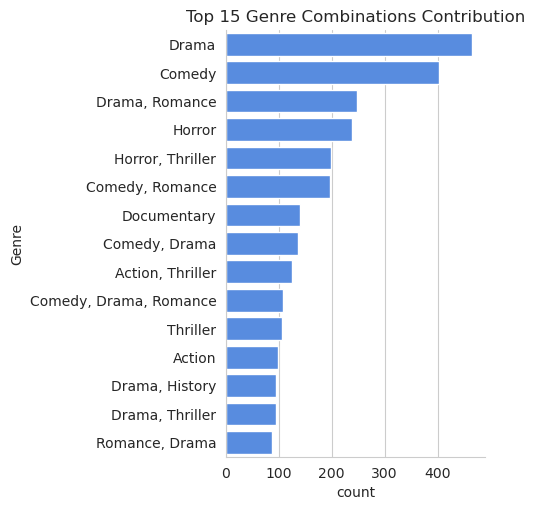

In [52]:
# Sirf top 15 sabse frequent genres nikalne ke liye
top_genres = df['Genre'].value_counts().head(15).index

# Unhi top 15 genres ko plot karna
sns.catplot(y='Genre', data=df, kind='count', order=top_genres, color='#4287f5')
plt.title('Top 15 Genre Combinations Contribution')
plt.show()

In [48]:
print(df['Genre'].count())

9826


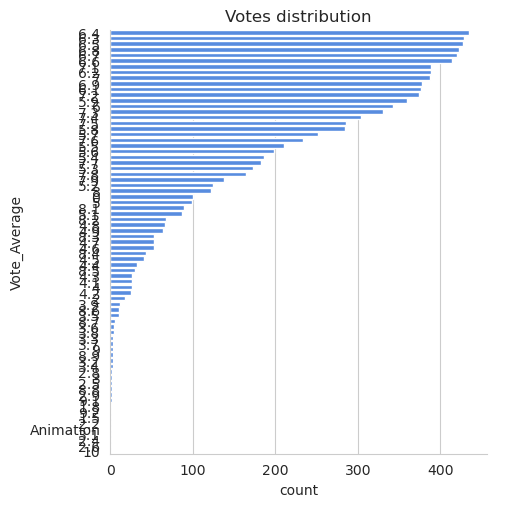

In [54]:
sns.catplot(y='Vote_Average', data=df, kind='count', order=df['Vote_Average'].value_counts().index, color='#4287f5')
plt.title('Votes distribution')
plt.show()

In [55]:
df[df['Popularity'] == df['Popularity'].max()]

,Release_Date,Title,Overview,Popularity,Vote_Count,Vote_Average,Original_Language,Genre,Poster_Url\r
0,15-12-2021,Spider-Man: No Way Home,Peter Parker is unmasked and no longer able to...,5083.954,8940,8.3,en,"Action, Adventure, Science Fiction",https://image.tmdb.org/t/p/original/1g0dhYtq4i...


In [57]:
df[df['Popularity'] == df['Popularity'].min()]

,Release_Date,Title,Overview,Popularity,Vote_Count,Vote_Average,Original_Language,Genre,Poster_Url\r
1115,- Magic Tricks,61.328,35,7.1,en,Animation,https://image.tmdb.org/t/p/original/6iXYe7AkQ1...,NaN,\r


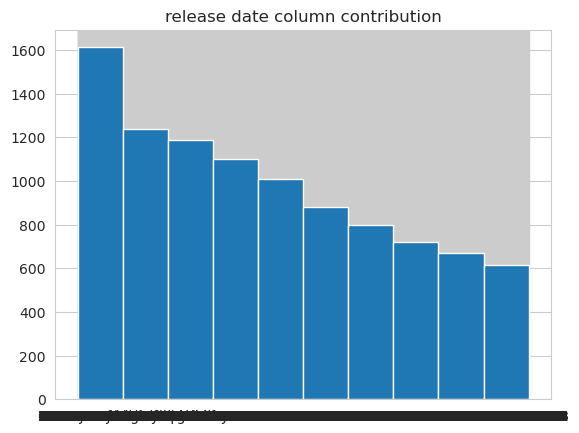

In [59]:
df['Release_Date'].hist()
plt.title('release date column contribution')
plt.show()